# Temporal EDA — Belgian house listings

The temporal axis matters more than
it first appears, because the model is trained on a temporally
ordered split (oldest 70% for training, the 15%r validation, the most recent 15% for test). If the price
distribution drifts within those windows, the validation and test
sets are not exchangeable, and the conformal calibration we apply on
the validation set will be miscalibrated on the test set.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "listings_raw.parquet"
WEB = ROOT / "data" / "listings_web.parquet"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

ACCENT = "#4f46e5"
ACCENT_2 = "#dc2626"
ACCENT_3 = "#15803d"

## 1. Load and align with the production cleaning rule

In [2]:
df = pd.read_parquet(RAW)
df = df[df["price"].between(20_000, 5_000_000)].copy()

# Cast both timestamp columns just in case parquet reads them oddly.
df["publication_creationDate"] = pd.to_datetime(df["publication_creationDate"], errors="coerce")
df["publication_lastModificationDate"] = pd.to_datetime(df["publication_lastModificationDate"], errors="coerce")

print(f"Rows after price filter : {len(df):,}")
print(f"Creation date range     : {df['publication_creationDate'].min()}  →  {df['publication_creationDate'].max()}")
print(f"Modification date range : {df['publication_lastModificationDate'].min()}  →  {df['publication_lastModificationDate'].max()}")
print(f"Creation NaT count      : {df['publication_creationDate'].isna().sum()}")
print(f"Modification NaT count  : {df['publication_lastModificationDate'].isna().sum()}")

Rows after price filter : 172,380
Creation date range     : 2008-12-05 13:36:00  →  2026-04-22 06:00:18.001000
Modification date range : 2024-04-23 02:48:59.967000  →  2026-04-22 06:12:37.005000
Creation NaT count      : 4
Modification NaT count  : 0


## 2. Two timestamps, two stories

Each listing carries two timestamps that the needs to keep
straight:

* `publication_creationDate` is when the listing first appeared online.
  It can sit very far in the past for properties that have been on
  the market for years.
* `publication_lastModificationDate` is when the listing was most
  recently touched (price update, photo update, status change).

The training script splits on the modification date, because that
matches the date at which the asking price snapshot was effectively
sealed. The notebook below uses both, and is careful to label which
one drives each chart.

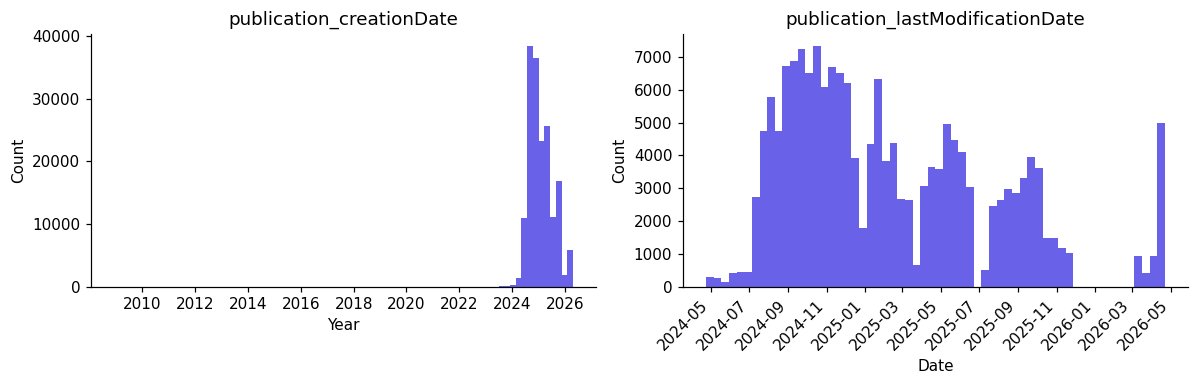

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(df["publication_creationDate"].dropna(), bins=80, color=ACCENT, alpha=0.85)
axes[0].set_title("publication_creationDate")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Count")
axes[0].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].hist(df["publication_lastModificationDate"].dropna(), bins=60, color=ACCENT, alpha=0.85)
axes[1].set_title("publication_lastModificationDate")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Count")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")
plt.tight_layout(); plt.show()

## 3. Listing flow per month

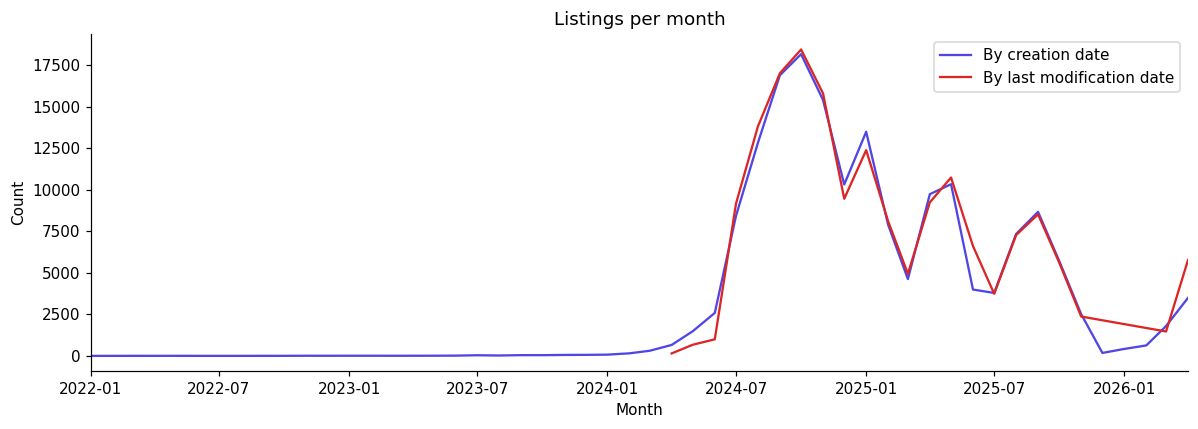

In [4]:
created_m = df["publication_creationDate"].dropna().dt.to_period("M").value_counts().sort_index()
modified_m = df["publication_lastModificationDate"].dropna().dt.to_period("M").value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(created_m.index.to_timestamp(), created_m.values, color=ACCENT, label="By creation date")
ax.plot(modified_m.index.to_timestamp(), modified_m.values, color=ACCENT_2, label="By last modification date")
ax.set_title("Listings per month")
ax.set_xlabel("Month"); ax.set_ylabel("Count")
ax.legend()
ax.set_xlim(pd.Timestamp("2022-01-01"), modified_m.index.max().to_timestamp())
plt.tight_layout(); plt.show()

### 3.1 Recent-12-month focus

Limit both axes to the 12months training window the production
pipeline uses. This is the slice the model actually learns from, so
this is the slice whose flow we care most about understanding.

Listings in the 12-month modeling window: 52,121


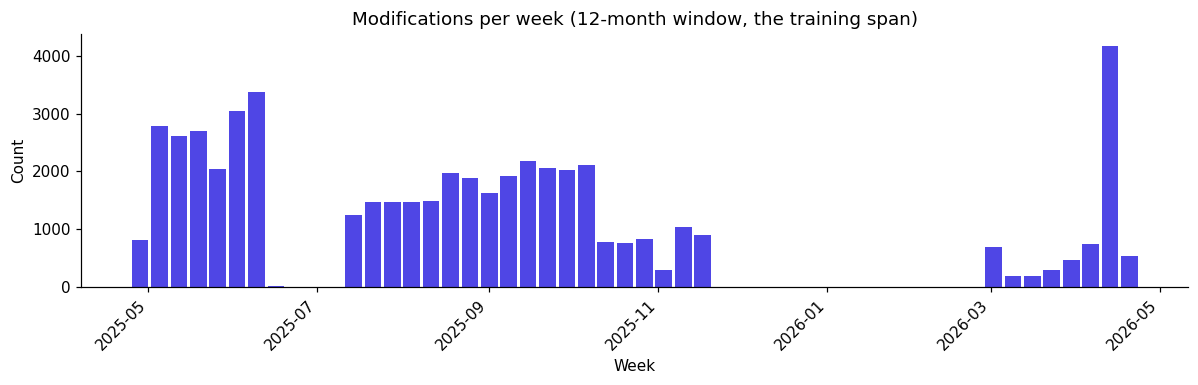

In [5]:
NOW = pd.Timestamp.utcnow().tz_localize(None).normalize()
WINDOW_START = NOW - pd.DateOffset(months=12)

window = df[df["publication_lastModificationDate"] >= WINDOW_START].copy()
print(f"Listings in the 12-month modeling window: {len(window):,}")

modified_w = window["publication_lastModificationDate"].dropna().dt.to_period("W").value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(modified_w.index.to_timestamp(), modified_w.values, color=ACCENT, width=6)
ax.set_title("Modifications per week (12-month window, the training span)")
ax.set_xlabel("Week"); ax.set_ylabel("Count")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout(); plt.show()

## 4. Days on market

We compute a per-listing "days on market" as the number of days
between the listing's creation date and now. This matches what the
production pipeline puts in the `days_on_market` column of the web
artefact, capped at three hundred and sixty five days so very old
publications do not drag the colormap.

In [6]:
df["days_on_market"] = (NOW - df["publication_creationDate"]).dt.days.clip(lower=0, upper=365)
dom = df["days_on_market"].dropna()
dom.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(0).astype("Int64")

count    172376
mean        329
std          77
min           8
5%          172
25%         347
50%         365
75%         365
95%         365
max         365
Name: days_on_market, dtype: Int64

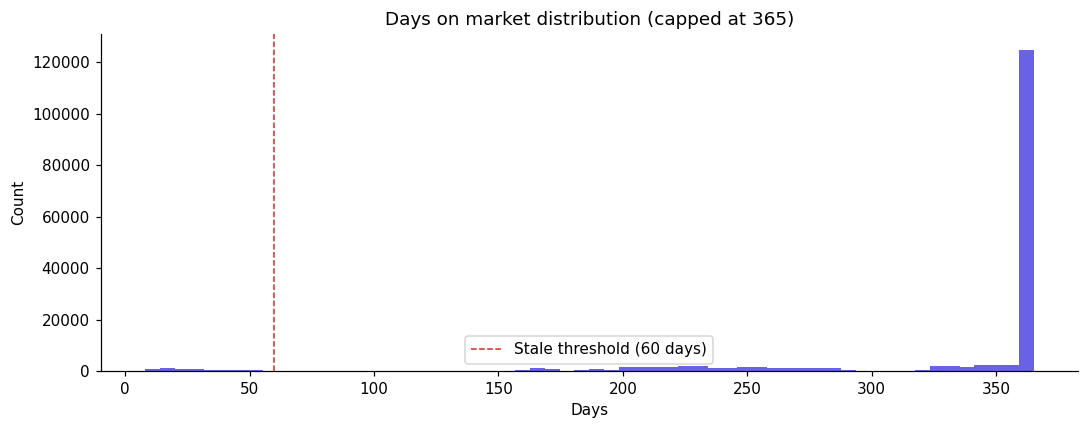

Listings older than 60 days: 167,086  (96.9%)


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dom, bins=60, color=ACCENT, alpha=0.85)
ax.axvline(60, color=ACCENT_2, linestyle="--", linewidth=1, label="Stale threshold (60 days)")
ax.set_title("Days on market distribution (capped at 365)")
ax.set_xlabel("Days"); ax.set_ylabel("Count")
ax.legend()
plt.tight_layout(); plt.show()

stale_pct = (dom > 60).mean()
print(f"Listings older than 60 days: {(dom > 60).sum():,}  ({stale_pct:.1%})")

### 4.1 Days on market vs verdict

The web artefact carries a per-listing `price_delta_pct`, which is
the relative gap between asking price and model fair value, so we pull
that file and look at how the gap evolves with time on market. The
intuition is that a listing that has not sold in 6 months is
more likely to be overpriced than one that just appeared, so the
distribution of `price_delta_pct` should shift to the right with
days on market.

In [8]:
web = pd.read_parquet(WEB)
web = web[web["days_on_market"].notna() & web["price_delta_pct"].notna()].copy()
web["dom_bin"] = pd.cut(web["days_on_market"],
                        bins=[-1, 7, 30, 60, 120, 365],
                        labels=["≤7d", "8–30d", "31–60d", "61–120d", ">120d"])

g = web.groupby("dom_bin", observed=True)["price_delta_pct"].agg(["median", "size"])
g["median_pct"] = (g["median"] * 100).round(1)
print(g[["size", "median_pct"]])

         size  median_pct
dom_bin                  
≤7d       612        0.90
8–30d    2781        1.40
31–60d   1142       -0.20
61–120d   875       -1.50
>120d     826        0.30


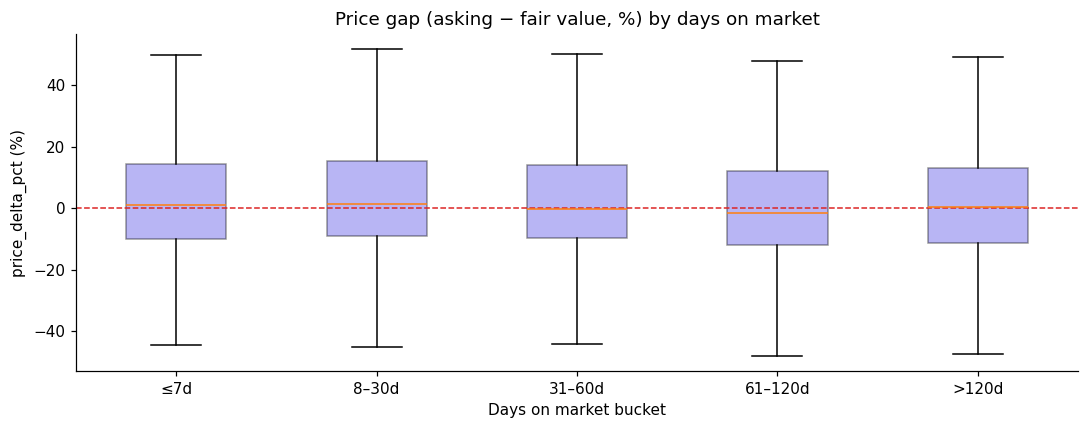

In [9]:
order = ["≤7d", "8–30d", "31–60d", "61–120d", ">120d"]
buckets = [web[web["dom_bin"] == o]["price_delta_pct"] * 100 for o in order]

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(buckets, tick_labels=order, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor=ACCENT, alpha=0.4))
ax.axhline(0, color=ACCENT_2, linewidth=1, linestyle="--")
ax.set_title("Price gap (asking − fair value, %) by days on market")
ax.set_xlabel("Days on market bucket"); ax.set_ylabel("price_delta_pct (%)")
plt.tight_layout(); plt.show()

## 5. Price drift over time

The single most important plot in this notebook: median asking price
by week within the twelve-month training window. If the curve is
flat, the validation and test sets are roughly exchangeable and the
conformal calibration is well behaved. If the curve drifts visibly,
calibration on the validation set is calibrating against the wrong
distribution, and the empirical coverage on the test set will fall
below target. This was our actual experience and the plot below
shows why.

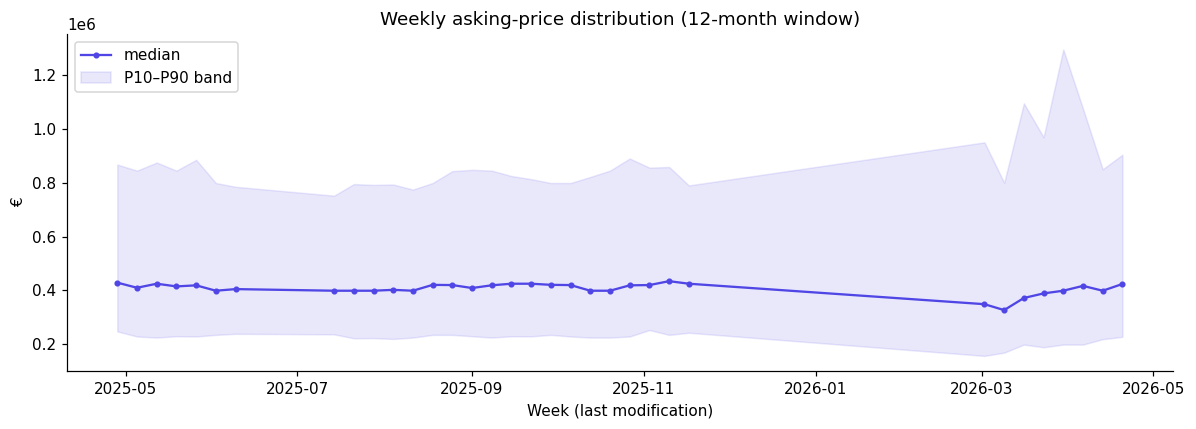

In [10]:
w = window.copy()
w["week"] = w["publication_lastModificationDate"].dt.to_period("W").dt.to_timestamp()
weekly = w.groupby("week").agg(
    n=("price", "size"),
    median_price=("price", "median"),
    p10_price=("price", lambda s: s.quantile(0.10)),
    p90_price=("price", lambda s: s.quantile(0.90)),
)
weekly = weekly[weekly["n"] >= 100]   # weeks too sparse to plot reliably

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(weekly.index, weekly["median_price"], color=ACCENT, marker="o", markersize=3, label="median")
ax.fill_between(weekly.index, weekly["p10_price"], weekly["p90_price"],
                color=ACCENT, alpha=0.12, label="P10–P90 band")
ax.set_title("Weekly asking-price distribution (12-month window)")
ax.set_xlabel("Week (last modification)"); ax.set_ylabel("€")
ax.legend()
plt.tight_layout(); plt.show()

### 5.1 The same picture for price per square meter

The raw price aggregates a size effect that may itself drift over
time (sellers listing larger or smaller properties in different
months). Plotting price per square meter removes the size effect
and exposes the underlying market-level drift more cleanly.

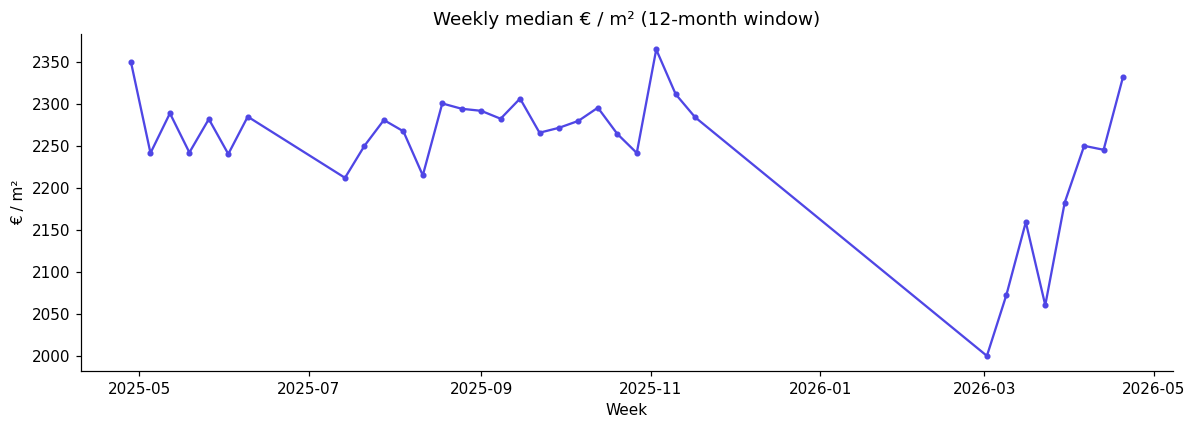

In [11]:
w["eur_per_m2"] = w["price"] / w["netHabitableSurface"].clip(lower=10)
weekly_m2 = w.groupby("week")["eur_per_m2"].agg(["median", "size"])
weekly_m2 = weekly_m2[weekly_m2["size"] >= 100]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(weekly_m2.index, weekly_m2["median"], color=ACCENT, marker="o", markersize=3)
ax.set_title("Weekly median € / m² (12-month window)")
ax.set_xlabel("Week"); ax.set_ylabel("€ / m²")
plt.tight_layout(); plt.show()

Here above we can see a "hole" in our data as the scraper was paused for a few months.

## 6. The temporal split, and the exchangeability problem

In [12]:
# Reproduce the split exactly as in scripts/02_train_model.py:
modeling = window.dropna(subset=["publication_lastModificationDate"]).copy()
modeling = modeling.sort_values("publication_lastModificationDate").reset_index(drop=True)
n = len(modeling)
i_train = int(n * 0.70)
i_val   = int(n * 0.85)

train = modeling.iloc[:i_train]
val   = modeling.iloc[i_train:i_val]
test  = modeling.iloc[i_val:]

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "n": [len(train), len(val), len(test)],
    "from": [s["publication_lastModificationDate"].min() for s in (train, val, test)],
    "to":   [s["publication_lastModificationDate"].max() for s in (train, val, test)],
    "median_price": [s["price"].median() for s in (train, val, test)],
    "median_eur_per_m2": [
        (s["price"] / s["netHabitableSurface"].clip(lower=10)).median()
        for s in (train, val, test)
    ],
})
split_summary

,split,n,from,to,median_price,median_eur_per_m2
0,train,36484,2025-05-01 00:00:25.034,2025-09-29 18:34:25.670,"415,000.00","2,268.97"
1,val,7818,2025-09-29 18:35:27.415,2025-11-18 11:03:58.014,"420,000.00","2,284.95"
2,test,7819,2025-11-18 11:03:58.166,2026-04-22 06:12:37.005,"399,000.00","2,215.28"


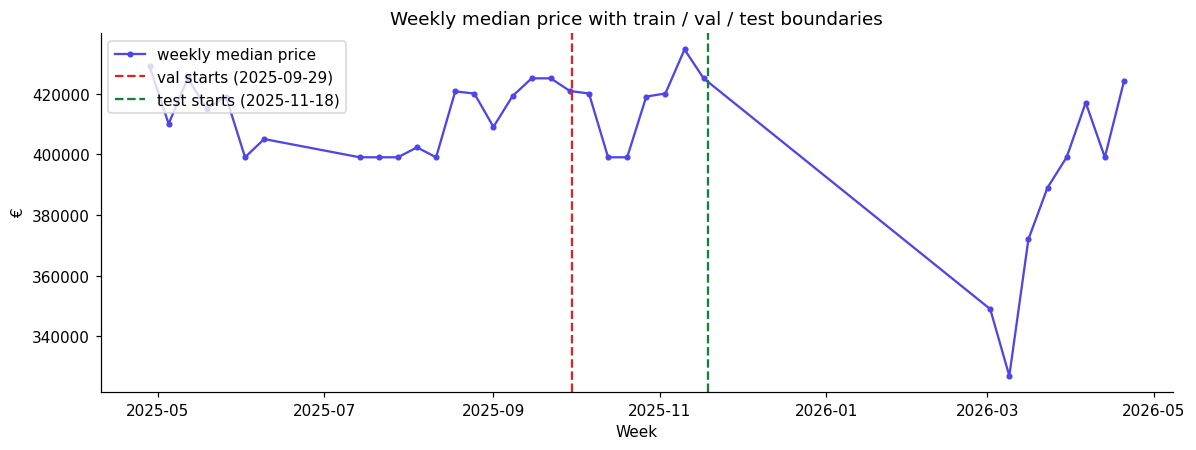

In [13]:
val_start = val["publication_lastModificationDate"].min()
test_start = test["publication_lastModificationDate"].min()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(weekly.index, weekly["median_price"], color=ACCENT, marker="o", markersize=3, label="weekly median price")
ax.axvline(val_start, color=ACCENT_2, linestyle="--", label=f"val starts ({val_start.date()})")
ax.axvline(test_start, color=ACCENT_3, linestyle="--", label=f"test starts ({test_start.date()})")
ax.set_title("Weekly median price with train / val / test boundaries")
ax.set_xlabel("Week"); ax.set_ylabel("€")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

### 6.1 Distribution shift between val and test

A more honest
diagnostic is to compare the full price distributions across the
three splits: not just their medians, but their shape. If the
distributions overlap closely, the conformal guarantee holds; if
they do not, calibration on the validation set will be off on the
test set in a direction set by the drift.

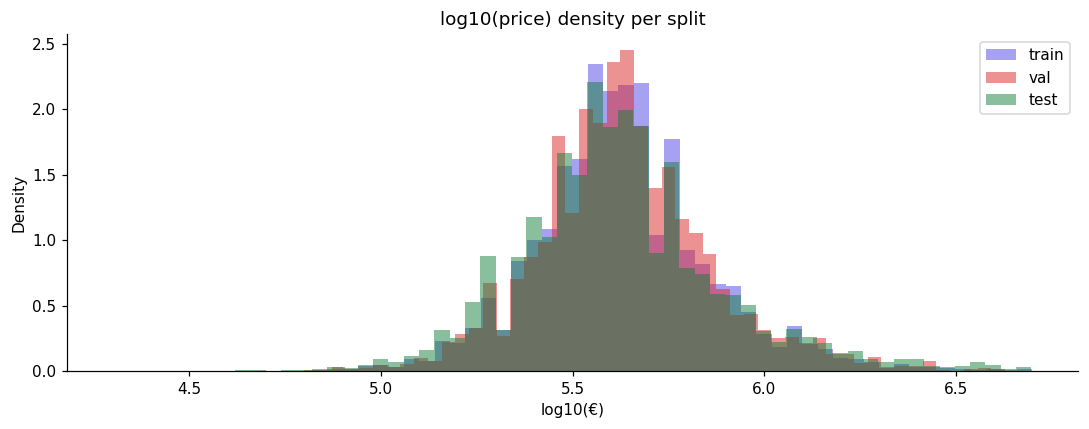

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
for s, name, color in [(train, "train", ACCENT),
                        (val, "val", ACCENT_2),
                        (test, "test", ACCENT_3)]:
    ax.hist(np.log10(s["price"].clip(lower=1)), bins=60, alpha=0.5, color=color, label=name, density=True)
ax.set_title("log10(price) density per split")
ax.set_xlabel("log10(€)"); ax.set_ylabel("Density")
ax.legend()
plt.tight_layout(); plt.show()

In [15]:
# Numeric quantification of the drift: percentage shift in the median.
shift_val = val["price"].median() / train["price"].median() - 1
shift_test = test["price"].median() / val["price"].median() - 1
print(f"Median price shift train -> val : {shift_val:+.2%}")
print(f"Median price shift val   -> test: {shift_test:+.2%}")

# Same in € / m².
m2_train = (train["price"] / train["netHabitableSurface"].clip(lower=10)).median()
m2_val   = (val["price"] / val["netHabitableSurface"].clip(lower=10)).median()
m2_test  = (test["price"] / test["netHabitableSurface"].clip(lower=10)).median()
print(f"Median €/m² shift train -> val : {m2_val / m2_train - 1:+.2%}")
print(f"Median €/m² shift val   -> test: {m2_test / m2_val - 1:+.2%}")

Median price shift train -> val : +1.20%
Median price shift val   -> test: -5.00%
Median €/m² shift train -> val : +0.70%
Median €/m² shift val   -> test: -3.05%


The numbers above will be the quantitative core of the article's
exchangeability argument. The shift between training and validation
is small which is why validation coverage looks
fine. The shift between validation and test is several times larger,
which is why test coverage falls below target and why no calibration
correction computed on the validation set can rescue the situation.

## 7. Seasonality

A complementary question, separate from drift: are there seasonal
patterns in either listing flow or pricing? Two very simple cuts:
listings created per month-of-year and per day-of-week. A clean
seasonal signal would give us a feature to consider for the model;
its absence (or smallness) is itself useful information.

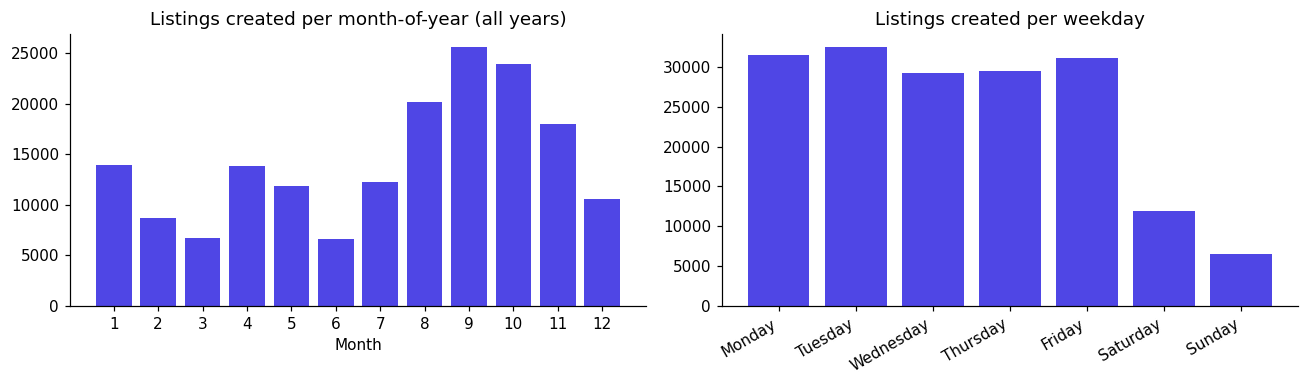

In [16]:
created = df["publication_creationDate"].dropna()
month_of_year = created.dt.month.value_counts().sort_index()
day_of_week = created.dt.day_name().value_counts().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].bar(month_of_year.index, month_of_year.values, color=ACCENT)
axes[0].set_xticks(range(1, 13))
axes[0].set_title("Listings created per month-of-year (all years)")
axes[0].set_xlabel("Month")

axes[1].bar(day_of_week.index, day_of_week.values, color=ACCENT)
axes[1].set_title("Listings created per weekday")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")
plt.tight_layout(); plt.show()

## 8. Modification velocity

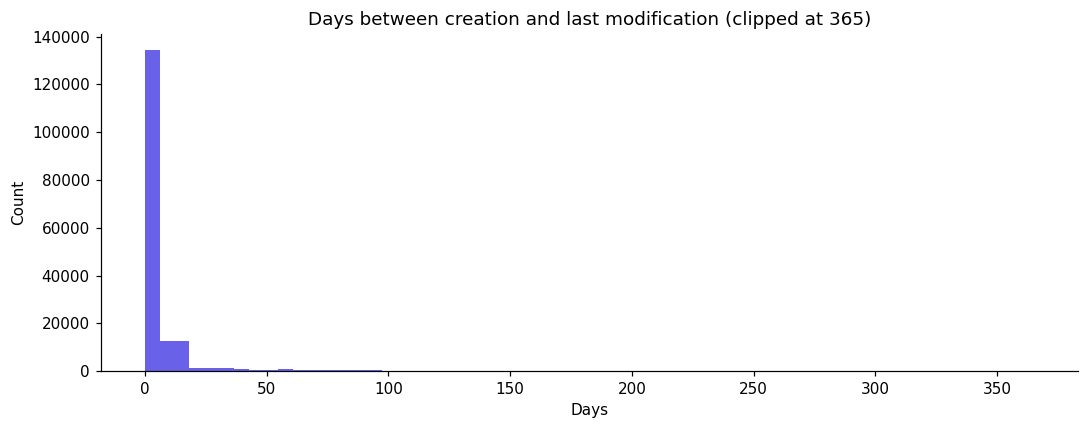

count   172,376.00
mean          8.40
std          36.40
min           0.00
5%            0.00
50%           0.10
90%          14.20
99%         147.00
max       5,730.10
Name: mod_minus_create_days, dtype: float64


In [17]:
df["mod_minus_create_days"] = (
    df["publication_lastModificationDate"] - df["publication_creationDate"]
).dt.total_seconds() / 86_400
delta = df["mod_minus_create_days"].dropna()
delta = delta[delta >= 0]  # negative deltas would be data errors

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(delta.clip(upper=365), bins=60, color=ACCENT, alpha=0.85)
ax.set_title("Days between creation and last modification (clipped at 365)")
ax.set_xlabel("Days"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

print(delta.describe(percentiles=[0.05, 0.5, 0.9, 0.99]).round(1))